In [7]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import librosa
import librosa.display
import pandas as pd
import matplotlib.pyplot as plt
import os
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch, Gain
import random

In [2]:
# Audio parameters
SAMPLE_RATE = 44100  # Hz, target sampling rate
DURATION = 4         # seconds, duration of audio segments
N_SAMPLES = SAMPLE_RATE * DURATION # Number of samples in 4 seconds

# Mel-spectrogram parameters
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

# Paths and directories
AUDIO_DATA_DIR = 'Model/SoundData/PreparedData'
METADATA_FILE = 'Model/SoundData/Metadata.csv'

In [3]:
def apply_augmentations(audio, sample_rate):
    """
    Applies defined augmentation transformations to the audio signal.
    """

    # Define transformations using audiomentations
    augment = Compose([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5), # Add Gaussian noise
        PitchShift(min_semitones=-2, max_semitones=2, p=0.5),           # Change pitch
        TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),                 # Stretch/compress time
        Gain(min_gain_db=-6.0, max_gain_db=6.0, p=0.5),            # Change volume
    ])
    return augment(samples=audio, sample_rate=sample_rate)

def audio_to_mel_spectrogram(audio, sample_rate, n_fft, hop_length, n_mels):
    """
    Transforms an audio signal into a Mel-spectrogram.
    """
    # Ensure audio is float32, which is standard for librosa
    audio = audio.astype(np.float32)

    # Compute Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    # Convert to decibel scale (logarithmic)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    #  Normalization (to 0-1 range)
    mel_spectrogram_norm = (mel_spectrogram_db - mel_spectrogram_db.min()) / \
                          (mel_spectrogram_db.max() - mel_spectrogram_db.min())
    return mel_spectrogram_norm

In [4]:
class WildBoarDataset(Dataset):
    def __init__(self, data_list, sample_rate, duration, n_fft, hop_length, n_mels, augment=True):
        """
        Initializes the Dataset.
        Args:
            data_list (list): List of dictionaries, each containing 'path' to an audio file and 'label'.
            sample_rate (int): Target sampling rate.
            duration (int): Target segment duration in seconds.
            n_fft, hop_length, n_mels: Mel-spectrogram parameters.
            augment (bool): Whether to apply data augmentation.
        """
        self.data_list = data_list
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_samples = sample_rate * duration
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.augment = augment

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item_info = self.data_list[idx]
        file_name = item_info['file_name'] # Use file_name from metadata
        label = item_info['label']

        # Construct full file path (assuming all files are in AUDIO_DATA_DIR)
        # We need to consider possible extensions (.wav, .mp3)
        # A common practice is to store filenames with extensions in metadata,
        # or try multiple extensions if metadata only has base name.
        # TODO in metadata store extension column
        file_path_wav = os.path.join(AUDIO_DATA_DIR, file_name + '.wav')
        file_path_mp3 = os.path.join(AUDIO_DATA_DIR, file_name + '.mp3')

        # Try loading .wav first, then .mp3
        if os.path.exists(file_path_wav):
            file_path = file_path_wav
        elif os.path.exists(file_path_mp3):
            file_path = file_path_mp3
        else:
            raise FileNotFoundError(f"Audio file not found for: {file_name} at {AUDIO_DATA_DIR} with .wav or .mp3 extension.")


        # 1. Load audio
        # librosa.load automatically converts to mono and resamples
        audio, sr = librosa.load(file_path, sr=self.sample_rate, mono=True)

        # Ensure the audio length is N_SAMPLES.
        # This should ideally be handled during the initial 4s segmentation and padding.
        # Adding checks here as a fallback.
        if len(audio) > self.n_samples:
            audio = audio[:self.n_samples]
        elif len(audio) < self.n_samples:
            padding = self.n_samples - len(audio)
            audio = np.pad(audio, (0, padding), 'constant')

        # 2. Data Augmentation
        if self.augment:
            audio = apply_augmentations(audio, self.sample_rate)

        # 3. Transform to Mel-spectrogram
        mel_spectrogram = audio_to_mel_spectrogram(
            audio, self.sample_rate, self.n_fft, self.hop_length, self.n_mels
        )

        # Convert to PyTorch tensor
        # Add a channel dimension (CNN expects (Batch_size, Channels, Height, Width))
        # A spectrogram is a grayscale image, so 1 channel.
        mel_spectrogram_tensor = torch.from_numpy(mel_spectrogram).unsqueeze(0).float()
        label_tensor = torch.tensor(label, dtype=torch.long) # Label as long for loss functions

        return mel_spectrogram_tensor, label_tensor

In [5]:
def create_data_list_from_metadata(metadata_path, audio_dir):
    df = pd.read_csv(metadata_path, sep=';')
    data_list = []
    for index, row in df.iterrows():
        quality = row['Quality']
        file_name_base = str(row['FileName']) # Ensure it's treated as string
        label = row['Label']
        if quality == 1:
            data_list.append({'file_name': file_name_base, 'label': label}) # Store base name, not full path yet

    random.shuffle(data_list) # Shuffle the list for randomness
    return data_list

# Create the data list from the metadata file
all_data_list = create_data_list_from_metadata(METADATA_FILE, AUDIO_DATA_DIR)
print(f"Total number of samples: {len(all_data_list)}")

# Split into training and validation sets (e.g., 80/20)
train_size = int(0.8 * len(all_data_list))
train_data = all_data_list[:train_size]
val_data = all_data_list[train_size:]

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")

Total number of samples: 945
Number of training samples: 756
Number of validation samples: 189


Shape of Mel-spectrogram: torch.Size([1, 128, 345])
Sample label: 0


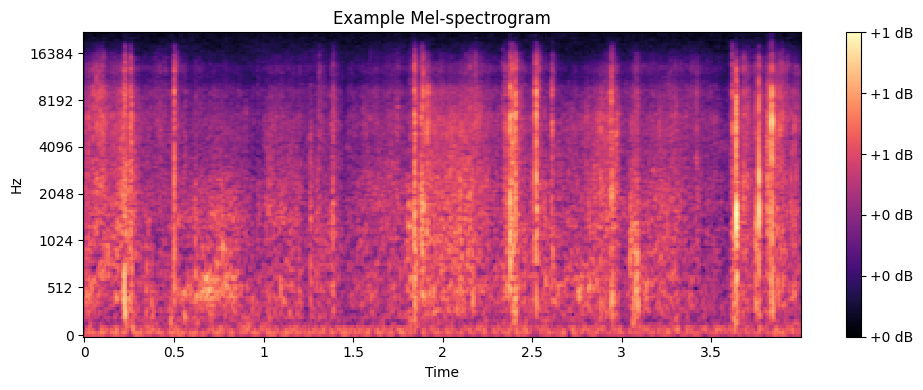

In [8]:
# Initialize datasets
train_dataset = WildBoarDataset(
    data_list=train_data,
    sample_rate=SAMPLE_RATE,
    duration=DURATION,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    augment=True # Augmentation for the training set
)

val_dataset = WildBoarDataset(
    data_list=val_data,
    sample_rate=SAMPLE_RATE,
    duration=DURATION,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    augment=False # No augmentation for the validation set
)

# Test the Dataset - fetch one sample and print its shape
try:
    sample_mel_spec, sample_label = train_dataset[0]
    print(f"Shape of Mel-spectrogram: {sample_mel_spec.shape}") # Expected shape: (1, N_MELS, num_frames)
    print(f"Sample label: {sample_label}")

    # Visualize an example Mel-spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(sample_mel_spec.squeeze().numpy(),
                             sr=SAMPLE_RATE, x_axis='time', y_axis='mel',
                             hop_length=HOP_LENGTH, cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Example Mel-spectrogram')
    plt.tight_layout()
    plt.show()
except FileNotFoundError as e:
    print(e)
    print("Please ensure your audio files are in the 'AUDIO_DATA_DIR' and metadata matches filenames.")

In [9]:
# Cell 8: Initialize DataLoaders

BATCH_SIZE = 32 # You can adjust this based on your GPU memory

# !!! IMPORTANT: For Windows, it's highly recommended to set num_workers=0
# or wrap the DataLoader initialization and usage in if __name__ == '__main__':
# Due to issues with multiprocessing context and object serialization in Jupyter on Windows.
# For initial debugging and smaller datasets, num_workers=0 is the safest bet.
NUM_WORKERS = 0 # <-- ZMIEŃ TO NA 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle training data
    num_workers=NUM_WORKERS,
    # persistent_workers=True if NUM_WORKERS > 0 else False # This line should be commented out or removed if NUM_WORKERS is 0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Do not shuffle validation data
    num_workers=NUM_WORKERS,
    # persistent_workers=True if NUM_WORKERS > 0 else False # This line should be commented out or removed if NUM_WORKERS is 0
)

print(f"Using num_workers: {NUM_WORKERS}")

# Test the DataLoader - fetch one batch
# This loop MUST be inside if __name__ == '__main__': block if NUM_WORKERS > 0 on Windows
# However, in Jupyter, the whole cell acts as __main__, so it's less straightforward
# to put a function definition here. The simplest way is to set NUM_WORKERS=0 for now.
try:
    for mel_specs, labels in train_loader:
        print(f"Shape of Mel-spectrogram batch: {mel_specs.shape}") # Expected: (BATCH_SIZE, 1, N_MELS, num_frames)
        print(f"Shape of labels batch: {labels.shape}") # Expected: (BATCH_SIZE,)
        break # Fetch only one batch for testing
    print("Successfully loaded a batch from DataLoader!")
except Exception as e:
    print(f"Error loading batch from DataLoader: {e}")
    print("Consider setting `num_workers=0` if you are on Windows or debugging multiprocessing issues.")

Using num_workers: 0
Shape of Mel-spectrogram batch: torch.Size([32, 1, 128, 345])
Shape of labels batch: torch.Size([32])
Successfully loaded a batch from DataLoader!


In [10]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np # Upewnij się, że numpy jest zaimportowany

# Parametry wejściowe spektrogramu (zdefiniowane wcześniej w notebooku)
# SAMPLE_RATE = 44100
# DURATION = 4
# N_FFT = 2048
# HOP_LENGTH = 512
# N_MELS = 128

# Oblicz oczekiwaną szerokość spektrogramu (liczbę ramek czasowych)
# Ta wartość musi być spójna z tym, co generuje funkcja audio_to_mel_spectrogram()
# Zakładamy, że N_SAMPLES = SAMPLE_RATE * DURATION jest prawidłowe
# num_frames = 1 + (SAMPLE_RATE * DURATION - N_FFT) // HOP_LENGTH
# Jeśli Twoja funkcja audio_to_mel_spectrogram używa paddingu do stałej długości,
# to num_frames może być po prostu (SAMPLE_RATE * DURATION) // HOP_LENGTH (jeśli N_FFT jest ignorowane dla długości)
# Użyjmy bezpiecznej wersji, która liczy jak librosa:
def calculate_num_frames(sample_rate, duration, n_fft, hop_length):
    total_samples = sample_rate * duration
    # librosa.feature.melspectrogram domyślnie przycina sygnał, jeśli jest za krótki
    # Lub zwraca tyle ramek, ile się zmieści.
    # Najbezpieczniej jest wyliczyć tak, jak robi to librosa:
    return 1 + (total_samples - n_fft) // hop_length

# Zastąp to swoimi faktycznymi stałymi:
# EXAMPLE_SAMPLE_RATE = 44100
# EXAMPLE_DURATION = 4
# EXAMPLE_N_FFT = 2048
# EXAMPLE_HOP_LENGTH = 512
# EXAMPLE_N_MELS = 128

# input_mel_height = EXAMPLE_N_MELS
# input_mel_width = calculate_num_frames(EXAMPLE_SAMPLE_RATE, EXAMPLE_DURATION, EXAMPLE_N_FFT, EXAMPLE_HOP_LENGTH)

# Przykład wartości, które powinny być zaimportowane lub zdefiniowane globalnie
# dla inicjalizacji modelu.
# W Twoim prawdziwym kodzie użyj stałych, których używasz w WildBoarDataset.
INPUT_MEL_HEIGHT = 128 # N_MELS zdefiniowane wcześniej
INPUT_MEL_WIDTH = 344 # Przykładowa wartość num_frames z poprzednich obliczeń (44100*4, n_fft=2048, hop_length=512)

class AudioClassifier(nn.Module):
    def __init__(self, num_classes, input_height, input_width):
        super(AudioClassifier, self).__init__()

        # Warstwa 1: Konwolucja 2D z pionowymi filtrami
        # kernel_size=(9, 3) oznacza filtr 9x3 piksele.
        # Wyższy wymiar dla osi Mel (pionowej) i mniejszy dla osi czasu (poziomej)
        # Padding (4,1) oznacza: (kernel_height-1)/2 = 4, (kernel_width-1)/2 = 1
        # Zapewnia to, że wymiary wyjściowe po konwolucji pozostają takie same jak wejściowe.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(9, 3), padding=(4, 1))
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2)) # Zmniejsza wymiary o połowę
        self.dropout_conv = nn.Dropout(0.25)

        # Warstwa 2: Kolejna konwolucja 2D
        # kernel_size=(3, 3) to standardowy filtr 3x3
        # padding=(1,1) utrzymuje wymiary
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), padding=(1, 1))
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2)) # Zmniejsza wymiary o połowę

        # Obliczenie rozmiaru warstwy spłaszczonej (dla pierwszej warstwy liniowej)
        # Po pool1: wysokość = input_height // 2, szerokość = input_width // 2
        # Po pool2: wysokość = (input_height // 2) // 2 = input_height // 4
        #            szerokość = (input_width // 2) // 2 = input_width // 4

        final_height_after_pooling = input_height // 4
        final_width_after_pooling = input_width // 4

        # Liczba kanałów po ostatniej warstwie konwolucyjnej to out_channels conv2 (128)
        self.flattened_features = 128 * final_height_after_pooling * final_width_after_pooling

        # Warstwy w pełni połączone (Fully Connected)
        self.fc1 = nn.Linear(self.flattened_features, 512)
        self.dropout_fc = nn.Dropout(0.25)
        self.fc2 = nn.Linear(512, num_classes) # num_classes to 2 (dzik/brak dzika)

    def forward(self, x):
        # x shape: (Batch_size, 1, input_height, input_width)
        # Warstwa 1
        x = self.pool1(F.relu(self.conv1(x)))
        # Warstwa 2
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.dropout_conv(x)

        # Spłaszczenie dla warstw w pełni połączonych
        x = x.view(x.size(0), -1) # -1 automatycznie oblicza wszystkie pozostałe wymiary

        # Warstwy w pełni połączone
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x) # Ponowne zastosowanie dropoutu
        x = self.fc2(x) # Ostatnia warstwa bez aktywacji (dla funkcji straty CrossEntropyLoss)
        return x

# --- Inicjalizacja Modelu (przykład, użyj swoich rzeczywistych wartości) ---
# NUM_CLASSES = 2 # Dzik / Brak dzika
# model = AudioClassifier(num_classes=NUM_CLASSES, input_height=INPUT_

In [11]:
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import time # Importowanie modułu time

# Sprawdzenie dostępności GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Parametry treningu ---
NUM_EPOCHS = 20        # Liczba epok treningowych
LEARNING_RATE = 0.001  # Szybkość uczenia optymalizatora
NUM_CLASSES = 2        # Liczba klas: 0 (brak dzika), 1 (dzik)

# --- Inicjalizacja Modelu ---
# Upewnij się, że INPUT_MEL_HEIGHT i INPUT_MEL_WIDTH są zdefiniowane i poprawne
# To powinny być N_MELS i num_frames z Twoich ustawień spektrogramu
# Upewnij się, że te zmienne są dostępne w tym kontekście (np. zdefiniowane globalnie w poprzednich komórkach)
# INPUT_MEL_HEIGHT = N_MELS # Zastąp N_MELS rzeczywistą wartością, np. 128
# INPUT_MEL_WIDTH = num_frames # Zastąp num_frames rzeczywistą wartością, np. 344

# Przykładowe wartości, jeśli nie masz ich zdefiniowanych z poprzednich sekcji
INPUT_MEL_HEIGHT = 128
INPUT_MEL_WIDTH = 344 # Ta wartość powinna pochodzić z Twoich obliczeń num_frames

model = AudioClassifier(num_classes=NUM_CLASSES, input_height=INPUT_MEL_HEIGHT, input_width=INPUT_MEL_WIDTH)
model.to(device) # Przeniesienie modelu na wybrane urządzenie (GPU/CPU)

# --- Definicja Funkcji Straty i Optymalizatora ---
criterion = nn.CrossEntropyLoss() # Standardowa funkcja straty dla problemów klasyfikacji wieloklasowej
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # Optymalizator Adam jest często dobrym wyborem

Using device: cpu


In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    print("\nStarting training...")
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    # Opcjonalnie: Zapisz najlepszy model
    best_val_accuracy = 0.0
    best_model_path = 'best_audio_classifier_model.pth'

    for epoch in range(num_epochs):
        start_time = time.time() # Start pomiaru czasu dla epoki

        # --- Faza Treningowa ---
        model.train() # Ustawienie modelu w tryb treningowy
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for batch_idx, (mel_specs, labels) in enumerate(train_loader):
            mel_specs = mel_specs.to(device)
            labels = labels.to(device)

            # Zerowanie gradientów
            optimizer.zero_grad()

            # Forward pass
            outputs = model(mel_specs)

            # Obliczenie straty
            loss = criterion(outputs, labels)

            # Backward pass i optymalizacja
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * mel_specs.size(0)

            # Zbieranie predykcji do obliczenia dokładności
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = accuracy_score(all_train_labels, all_train_preds)
        history['train_loss'].append(epoch_train_loss)
        history['train_accuracy'].append(epoch_train_accuracy)

        # --- Faza Walidacyjna ---
        model.eval() # Ustawienie modelu w tryb ewaluacji
        val_running_loss = 0.0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad(): # Wyłączenie obliczania gradientów dla walidacji
            for mel_specs, labels in val_loader:
                mel_specs = mel_specs.to(device)
                labels = labels.to(device)

                outputs = model(mel_specs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * mel_specs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = accuracy_score(all_val_labels, all_val_preds)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)

        end_time = time.time() # Koniec pomiaru czasu dla epoki
        epoch_duration = end_time - start_time # Obliczenie czasu trwania epoki

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
              f"Time: {epoch_duration:.2f}s")

        # Zapisz model, jeśli poprawiła się dokładność walidacji
        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            torch.save(model.state_dict(), best_model_path)
            print(f"Model saved! Best Val Acc: {best_val_accuracy:.4f} (Epoch {epoch+1})")

    print("\nTraining complete!")
    print(f"Best model saved to: {best_model_path}")
    return history

# --- Uruchomienie Treningu ---
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, device)

In [13]:
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, device)


Starting training...
Epoch 1/20: Train Loss: 6.7485, Train Acc: 0.5437 | Val Loss: 0.6935, Val Acc: 0.4392
Epoch 2/20: Train Loss: 0.6697, Train Acc: 0.6098 | Val Loss: 0.6710, Val Acc: 0.5608
Epoch 3/20: Train Loss: 0.6437, Train Acc: 0.5979 | Val Loss: 0.6547, Val Acc: 0.5608
Epoch 4/20: Train Loss: 0.6228, Train Acc: 0.5979 | Val Loss: 0.6581, Val Acc: 0.5661
Epoch 5/20: Train Loss: 0.6127, Train Acc: 0.6415 | Val Loss: 0.6119, Val Acc: 0.6455
Epoch 6/20: Train Loss: 0.5635, Train Acc: 0.7143 | Val Loss: 0.4798, Val Acc: 0.7725
Epoch 7/20: Train Loss: 0.4289, Train Acc: 0.7963 | Val Loss: 0.4152, Val Acc: 0.7460
Epoch 8/20: Train Loss: 0.4198, Train Acc: 0.7897 | Val Loss: 0.3625, Val Acc: 0.8413
Epoch 9/20: Train Loss: 0.3539, Train Acc: 0.8439 | Val Loss: 0.2868, Val Acc: 0.8836
Epoch 10/20: Train Loss: 0.3455, Train Acc: 0.8452 | Val Loss: 0.2757, Val Acc: 0.9101
Epoch 11/20: Train Loss: 0.2931, Train Acc: 0.8796 | Val Loss: 0.2504, Val Acc: 0.9206
Epoch 12/20: Train Loss: 0.276

In [14]:
model

AudioClassifier(
  (conv1): Conv2d(1, 64, kernel_size=(9, 3), stride=(1, 1), padding=(4, 1))
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=352256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

In [16]:
torch.save(model.state_dict(), 'modelv1.pth')

In [ ]:
#TODO odpal i przetestuj to
# --- Definicja Funkcji Treningowej dla pojedynczego przebiegu ---
def train_and_evaluate_final_model(model, train_loader, val_loader, test_loader,
                                   criterion, optimizer, num_epochs, device):

    print("\n--- Starting final model training ---")

    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    best_val_accuracy = 0.0
    best_model_path = 'final_best_audio_classifier_model.pth' # Ścieżka dla najlepszego modelu

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- Faza Treningowa ---
        model.train()
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for mel_specs, labels in train_loader:
            mel_specs = mel_specs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(mel_specs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * mel_specs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = accuracy_score(all_train_labels, all_train_preds)
        history['train_loss'].append(epoch_train_loss)
        history['train_accuracy'].append(epoch_train_accuracy)

        # --- Faza Walidacyjna ---
        model.eval()
        val_running_loss = 0.0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for mel_specs, labels in val_loader:
                mel_specs = mel_specs.to(device)
                labels = labels.to(device)

                outputs = model(mel_specs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * mel_specs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = accuracy_score(all_val_labels, all_val_preds)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)

        end_time = time.time()
        epoch_duration = end_time - start_time

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
              f"Time: {epoch_duration:.2f}s")

        # Zapisz najlepszy model na podstawie dokładności walidacji
        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            torch.save(model.state_dict(), best_model_path)
            print(f"Model saved! Best Val Acc: {best_val_accuracy:.4f} (Epoch {epoch+1})")

    print("\n--- Training complete! ---")
    print(f"Best model saved to: {best_model_path}")

    # --- Faza Testowa po zakończeniu treningu ---
    print(f"\n--- Evaluating final model on Test Set ---")

    # Wczytaj najlepszy zapisany model do oceny na zbiorze testowym
    model.load_state_dict(torch.load(best_model_path))
    model.eval() # Ustaw model w tryb ewaluacji

    all_test_preds = []
    all_test_labels = []
    test_loss = 0.0

    with torch.no_grad():
        for mel_specs, labels in test_loader:
            mel_specs = mel_specs.to(device)
            labels = labels.to(device)
            outputs = model(mel_specs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * mel_specs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

    test_accuracy = accuracy_score(all_test_labels, all_test_preds)
    test_f1 = f1_score(all_test_labels, all_test_preds, average='binary')
    test_precision = precision_score(all_test_labels, all_test_preds, average='binary')
    test_recall = recall_score(all_test_labels, all_test_preds, average='binary')
    cm = confusion_matrix(all_test_labels, all_test_preds)

    test_loss /= len(test_loader.dataset)

    print(f"Final Model Test Results:")
    print(f"  Loss: {test_loss:.4f}")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  F1 Score: {test_f1:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return history, {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'confusion_matrix': cm
    }


# --- Uruchomienie Treningu ---
# Inicjalizacja modelu, funkcji straty i optymalizatora
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Zapewnij, że INPUT_MEL_HEIGHT i INPUT_MEL_WIDTH są zdefiniowane i poprawne
# N_MELS = 128
# SAMPLE_RATE = 44100
# DURATION = 4
# N_FFT = 2048
# HOP_LENGTH = 512
# INPUT_MEL_HEIGHT = N_MELS
# INPUT_MEL_WIDTH = 1 + (SAMPLE_RATE * DURATION - N_FFT) // HOP_LENGTH

NUM_EPOCHS = 20
LEARNING_RATE = 0.001
NUM_CLASSES = 2

# Upewnij się, że klasa AudioClassifier jest dostępna (zaimportowana lub zdefiniowana)
# class AudioClassifier: ... (Twoja definicja modelu)
# Przykładowa (jeśli nie jest zdefiniowana)
import torch.nn as nn
import torch.nn.functional as F
class AudioClassifier(nn.Module):
    def __init__(self, num_classes, input_height, input_width):
        super(AudioClassifier, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(9, 3), padding=(4, 1))
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.dropout1 = nn.Dropout(0.25) # Zgodnie z decyzją o 3 miejscach

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), padding=(1, 1))
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.dropout2 = nn.Dropout(0.25) # Zgodnie z decyzją o 3 miejscach

        self.final_height = input_height // 4
        self.final_width = input_width // 4
        self.flattened_features = 128 * self.final_height * self.final_width

        self.fc1 = nn.Linear(self.flattened_features, 512)
        self.dropout_fc = nn.Dropout(0.25) # Zgodnie z decyzją o 3 miejscach

        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.dropout1(x)

        x = self.pool2(F.relu(self.conv2(x)))
        x = self.dropout2(x)

        x = x.view(x.size(0), -1) # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)

        x = self.fc2(x)
        return x


model = AudioClassifier(num_classes=NUM_CLASSES, input_height=INPUT_MEL_HEIGHT, input_width=INPUT_MEL_WIDTH)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

training_history, final_test_results = train_and_evaluate_final_model(
    model, train_loader, val_loader, test_loader,
    criterion, optimizer, NUM_EPOCHS, device
)